In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

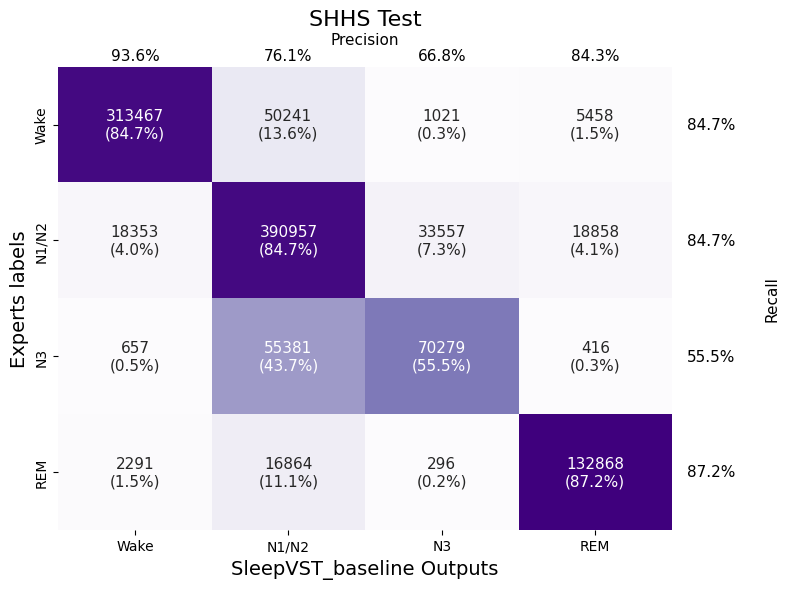

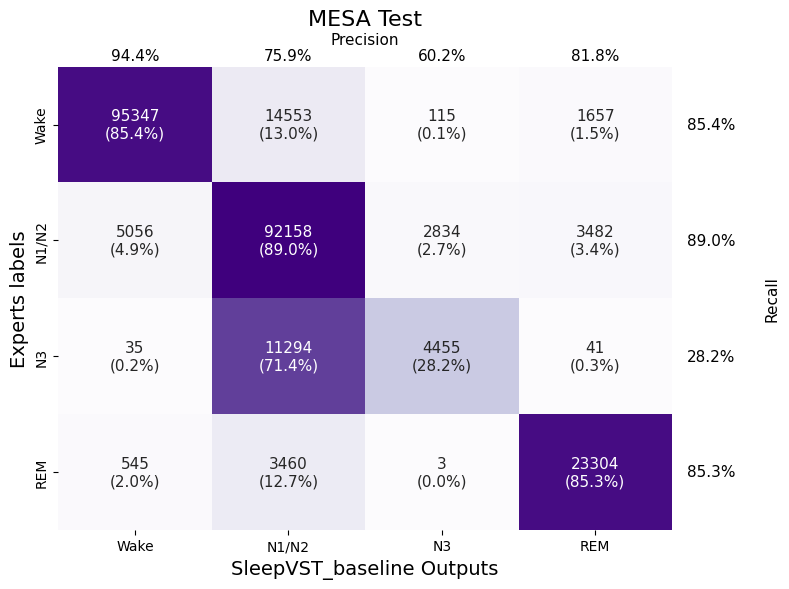

In [ ]:
labels = ['Wake', 'N1/N2', 'N3', 'REM']

shhs_cm = np.array([[313467,  50241 ,  1021 ,  5458],
 [ 18353, 390957,  33557,  18858],
 [   657 , 55381 , 70279 ,   416],
 [  2291 , 16864,   296 ,132868]])

# 정규화된 confusion matrix
shhs_cm_percent = np.array([[84.7, 13.6,  0.3,  1.5],
 [ 4.,  84.7,  7.3,  4.1],
 [ 0.5, 43.7,55.5 , 0.3],
 [ 1.5 ,11.1,  0.2, 87.2]])
precision_shhs = np.array([93.6, 76.1, 66.8, 84.3])
recall_shhs = np.array([84.7, 84.7, 55.5, 87.2])

mesa_cm = np.array([[95347, 14553,   115 , 1657],
 [ 5056, 92158,  2834,  3482],
 [   35, 11294 , 4455 ,   41],
 [  545 , 3460,     3, 23304]])

mesa_cm_percent = np.array([[85.4, 13.  , 0.1,  1.5],
 [ 4.9 ,89.,   2.7,  3.4],
 [ 0.2 ,71.4 ,28.2,  0.3],
 [ 2. , 12.7  ,0.,  85.3]]
)
precision_mesa = np.array([94.4, 75.9, 60.2, 81.8])
recall_mesa = np.array([85.4, 89., 28.2, 85.3])

annot_shhs = np.empty_like(shhs_cm).astype(str)
for i in range(shhs_cm.shape[0]):
    for j in range(shhs_cm.shape[1]):
        annot_shhs[i, j] = f"{shhs_cm[i, j]}\n({shhs_cm_percent[i, j]:.1f}%)"
# pandas DataFrame으로 바꾸기
df_shhs = pd.DataFrame(shhs_cm_percent, index=labels, columns=labels)


fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(df_shhs, annot=annot_shhs, fmt='', cmap='Purples', cbar=False,
            linewidths=0, square=False,
            annot_kws={"size": 11})
# precision 텍스트를 x축 위에 추가
for i, p in enumerate(precision_shhs):
    ax.text(i + 0.5, -0.1, f'{p:.1f}%', ha='center', va='center', fontsize=11)

# recall 텍스트를 y축 오른쪽에 추가
for i, r in enumerate(recall_shhs):
    ax.text(len(labels) + 0.1, i + 0.5, f'{r:.1f}%', va='center', fontsize=11)

ax.text(len(labels)/2, -0.2, 'Precision', ha='center', fontsize=11)
ax.text(len(labels) + 0.4, len(labels)/2, 'Recall', va='center', rotation=90, fontsize=11)
plt.ylabel('Experts labels', fontsize=14)
plt.xlabel('SleepVST_baseline Outputs', fontsize=14)
plt.title('SHHS Test', fontsize=16, pad=30)
plt.tight_layout()
plt.savefig('shhs_cm.png', dpi=600, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

annot_mesa = np.empty_like(mesa_cm).astype(str)
for i in range(mesa_cm.shape[0]):
    for j in range(mesa_cm.shape[1]):
        annot_mesa[i, j] = f"{mesa_cm[i, j]}\n({mesa_cm_percent[i, j]:.1f}%)"
# pandas DataFrame으로 바꾸기

df_mesa = pd.DataFrame(mesa_cm_percent, index=labels, columns=labels)

# 시각화
sns.heatmap(df_mesa, annot=annot_mesa, fmt='', cmap='Purples', cbar=False,
            linewidths=0, square=False,
            annot_kws={"size": 11})
# precision 텍스트를 x축 위에 추가
for i, p in enumerate(precision_mesa):
    ax.text(i + 0.5, -0.1, f'{p:.1f}%', ha='center', va='center', fontsize=11)

# recall 텍스트를 y축 오른쪽에 추가
for i, r in enumerate(recall_mesa):
    ax.text(len(labels) + 0.1, i + 0.5, f'{r:.1f}%', va='center', fontsize=11)

ax.text(len(labels)/2, -0.2, 'Precision', ha='center', fontsize=11)
ax.text(len(labels) + 0.4, len(labels)/2, 'Recall', va='center', rotation=90, fontsize=11)
plt.ylabel('Experts labels', fontsize=14)
plt.xlabel('SleepVST_baseline Outputs', fontsize=14)
plt.title('MESA Test', fontsize=16, pad=30)
plt.tight_layout()
plt.savefig('mesa_cm.png', dpi=600, bbox_inches='tight')
plt.show()

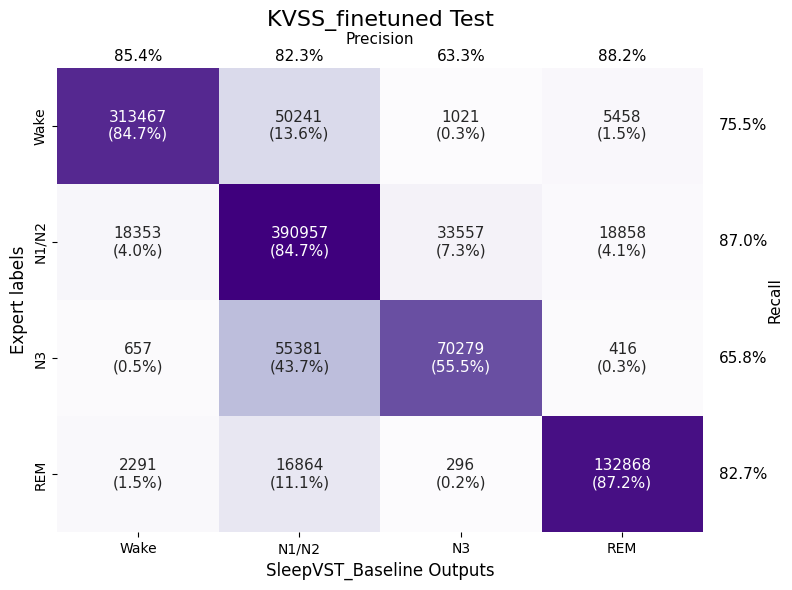

In [72]:
labels = ['Wake', 'N1/N2', 'N3', 'REM']

kvss_cm = np.array([[10164 , 2918 ,   12  , 375],
 [ 1431 ,29135,  2311 ,  623],
 [   59 , 1977,  4016,    50],
 [  246 , 1383 ,    3 , 7814]])

# 정규화된 confusion matrix
kvss_cm_percent = np.array([[75.5 ,21.7 , 0.1 , 2.8],
 [ 4.3 ,87. ,  6.9  ,1.9],
 [ 1.,  32.4, 65.8,  0.8],
 [ 2.6 ,14.6,  0.,  82.7]])

precision_kvss = np.diag(kvss_cm) / np.sum(kvss_cm, axis=0) * 100
recall_kvss = np.diag(kvss_cm) / np.sum(kvss_cm, axis=1) * 100

annot_kvss = np.empty_like(kvss_cm).astype(str)
for i in range(kvss_cm.shape[0]):
    for j in range(kvss_cm.shape[1]):
        annot_kvss[i, j] = f"{kvss_cm[i, j]}\n({kvss_cm_percent[i, j]:.1f}%)"
# pandas DataFrame으로 바꾸기
df_kvss = pd.DataFrame(kvss_cm_percent, index=labels, columns=labels)
# 시각화
# Precision / Recall (가상의 값)
precision = [85.4, 82.3, 63.3, 88.2]  # column 기준
recall    = [75.5, 87., 65.8, 82.7]  # row 기준

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_kvss, annot=annot_shhs, fmt='', cmap='Purples', cbar=False,
            linewidths=0, square=False,
            annot_kws={"size": 11})

# precision 텍스트를 x축 위에 추가
for i, p in enumerate(precision):
    ax.text(i + 0.5, -0.1, f'{p:.1f}%', ha='center', va='center', fontsize=11)

# recall 텍스트를 y축 오른쪽에 추가
for i, r in enumerate(recall):
    ax.text(len(labels) + 0.1, i + 0.5, f'{r:.1f}%', va='center', fontsize=11)
    
# 상단/우측 제목
ax.text(len(labels)/2, -0.2, 'Precision', ha='center', fontsize=11)
ax.text(len(labels) + 0.4, len(labels)/2, 'Recall', va='center', rotation=90, fontsize=11)

plt.ylabel('Expert labels', fontsize=12)
plt.xlabel('SleepVST_Baseline Outputs', fontsize=12)
plt.title('KVSS_finetuned Test', fontsize=16, pad=30)
plt.tight_layout()
plt.savefig('kvss_cm.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
labels = ['Wake', 'N1/N2', 'N3', 'REM']

kvss_cm = np.array([[4512625,  658174,   15619,  115506],
 [ 381780, 8170896,  750648,  428018],
 [  14817, 1243154, 1440685,   12508],
 [  48027,  332132,    8452, 2912079]])

# 정규화된 confusion matrix
kvss_cm_percent = np.array([[85.1, 12.4,  0.3,  2.2],
 [ 3.9, 84.,   7.7,  4.4],
 [ 0.5, 45.9, 53.1,  0.5],
 [ 1.5, 10.1,  0.3, 88.2]])

precision_kvss = np.diag(kvss_cm) / np.sum(kvss_cm, axis=0) * 100
recall_kvss = np.diag(kvss_cm) / np.sum(kvss_cm, axis=1) * 100

annot_kvss = np.empty_like(kvss_cm).astype(str)
for i in range(kvss_cm.shape[0]):
    for j in range(kvss_cm.shape[1]):
        annot_kvss[i, j] = f"{kvss_cm[i, j]}\n({kvss_cm_percent[i, j]:.1f}%)"
# pandas DataFrame으로 바꾸기
df_kvss = pd.DataFrame(kvss_cm_percent, index=labels, columns=labels)
# 시각화
# Precision / Recall (가상의 값)
precision = [89.9, 72.7, 75.7, 71.9]  # column 기준
recall    = [91.7, 66.0, 78.5, 81.1]  # row 기준

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_kvss, annot=annot_shhs, fmt='', cmap='Purples', cbar=False,
            linewidths=0, square=True,
            annot_kws={"size": 11})

# precision 텍스트를 x축 위에 추가
for i, p in enumerate(precision):
    ax.text(i + 0.5, -0.3, f'{p:.1f}%', ha='center', va='center', fontsize=11)

# recall 텍스트를 y축 오른쪽에 추가
for i, r in enumerate(recall):
    ax.text(len(labels) + 0.1, i + 0.5, f'{r:.1f}%', va='center', fontsize=11)
    
    # 상단/우측 제목
ax.text(len(labels)/2, -0.4, 'Precision', ha='center', fontsize=11)
ax.text(len(labels) + 0.6, len(labels)/2, 'Recall', va='center', rotation=90, fontsize=11)

plt.ylabel('Expert labels', fontsize=12)
plt.xlabel('SleepVST_kvss_finetuned', fontsize=12)
# plt.title('KVSS Test', fontsize=16)
plt.tight_layout()
plt.savefig('kvss_cm.png', dpi=600, bbox_inches='tight')
plt.show()